>
> # Scenario analysis - Gini coefficient
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [1]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
from scenarios import *
from plot_func import *
import seaborn as sns
import matplotlib.collections
plt.rc('font', size=15)
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15)

In [2]:
# Enter variable and data type
variable_1 = {"name": "gini", "sym": "$G$", "int": False, "pos": 2} # pos = position of variable name in zip name
variables = {"variable_1": variable_1}

In [3]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variables["variable_1"]["name"])
res, micro, params, drivers, requests, var_val, all_pax = load_results(dir_name, variables)

# Find variable values that have been tested
vals, scn = find_vals(var_val, variables)

In [4]:
# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res, all_pax)

In [5]:
for i in range(len(res.sup)):
    if 'rejected_reg' not in res.sup[i].columns:
        res.sup[i]['rejected_reg'] = np.zeros(len(res.sup[i].index))
        res.sup[i]['reject_particip'] = np.zeros(len(res.sup[i].index))

In [6]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl.head(3)

all replications have converged


,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged
0,41,119.006625,37,1443.348249,41,True
1,9,161.563353,36,1491.052055,36,True
2,41,106.820022,35,1471.111503,41,True


In [7]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 3/0 for scenario 0.0
Sufficient number of replications: 3/0 for scenario 0.05
Sufficient number of replications: 8/4 for scenario 0.1
Sufficient number of replications: 4/2 for scenario 0.15
Sufficient number of replications: 4/2 for scenario 0.2
Sufficient number of replications: 5/1 for scenario 0.25
Sufficient number of replications: 3/1 for scenario 0.3
Sufficient number of replications: 3/1 for scenario 0.35
Sufficient number of replications: 3/1 for scenario 0.4
Sufficient number of replications: 3/1 for scenario 0.45
Sufficient number of replications: 3/1 for scenario 0.5
Sufficient number of replications: 3/1 for scenario 0.55
Sufficient number of replications: 3/1 for scenario 0.6
Sufficient number of replications: 3/1 for scenario 0.65
Sufficient number of replications: 3/1 for scenario 0.7
Sufficient number of replications: 3/1 for scenario 0.75
Sufficient number of replications: 3/1 for scenario 0.8
Sufficient number of replications: 3/1 f

In [8]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [9]:
eql_scn.dem.head(5)

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,...,std_exp_wait,std_corr_wait,std_perc_wait_req,cons_surplus,pickup_time,match_time,corr_match_time,extra_bike,extra_pt,extra_car
scenario,,,,,,,,,,,,,,,,,,,,,
0.00,16538.0,151.066667,0.000000,0.000,NaN,1800.000000,1656.159190,1569.489841,13346.333333,1757.333333,...,NaN,0.000000,311.942220,9.823645,NaN,NaN,NaN,41820.333333,5116.666667,9181.666667
0.05,18255.0,151.533333,0.000000,0.000,NaN,1800.000000,1675.317652,1579.746994,14626.000000,2061.000000,...,NaN,0.000000,319.965986,9.249856,NaN,NaN,NaN,40586.666667,4961.000000,8922.000000
0.10,21182.5,284.500000,0.617517,178.325,596.655283,1052.790968,1227.788948,1066.839593,16603.675000,2712.800000,...,307.524615,590.747540,357.413625,30.296181,389.310069,207.345214,NaN,38706.750000,4764.875000,8250.750000
0.15,23081.5,581.500000,0.943309,548.850,445.724960,521.221730,685.283217,572.366860,17531.350000,3300.950000,...,295.865167,415.436858,250.058269,107.518101,373.441555,72.283405,NaN,37571.750000,4690.000000,7728.500000
0.20,23872.0,913.900000,0.993139,907.700,258.062314,268.493694,386.781735,332.762865,17582.000000,3694.300000,...,213.848615,242.994453,168.501691,248.216490,249.480886,8.581427,NaN,37235.250000,4729.000000,7325.500000


In [10]:
eql_scn.sup.head(5)

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,driver_surplus,mean_rev,mean_op_costs,ivt_costs,dh_costs,mean_dh_dist,mean_dh_time,drive_time,not_idle_time,share_idle_time
scenario,,,,,,,,,,,,,,,,,,,,,
0.00,2500.0,0.000,0.0,0.000,0.0,114.484359,NaN,NaN,NaN,0.572422,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.05,2500.0,0.000,0.0,0.000,0.0,122.288158,NaN,NaN,NaN,0.615843,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.10,2500.0,63.525,0.0,4.925,0.0,133.357334,132.847539,132.341527,133.947121,0.689604,...,-1239.534131,206.654617,72.707496,36.578253,36.129243,144.516970,14451.697043,14631.301274,29082.998316,-0.009826
0.15,2500.0,75.550,0.0,18.350,0.0,121.702856,121.610281,120.419877,120.630173,0.654309,...,-1163.131647,181.831380,61.201206,32.847540,28.353667,113.414667,11341.466653,13139.015904,24480.482557,0.149983
0.20,2500.0,96.400,0.0,40.250,0.0,108.412867,108.494325,107.679084,105.139620,0.615029,...,-974.419987,146.150610,41.010990,26.820432,14.190559,56.762235,5676.223509,10728.172637,16404.396146,0.430403


In [11]:
eql_scn.plf.head(5)

,plat_profit
0.00,242.050825
0.05,257.111925
0.10,527.486400
0.15,1168.867875
0.20,1968.077662


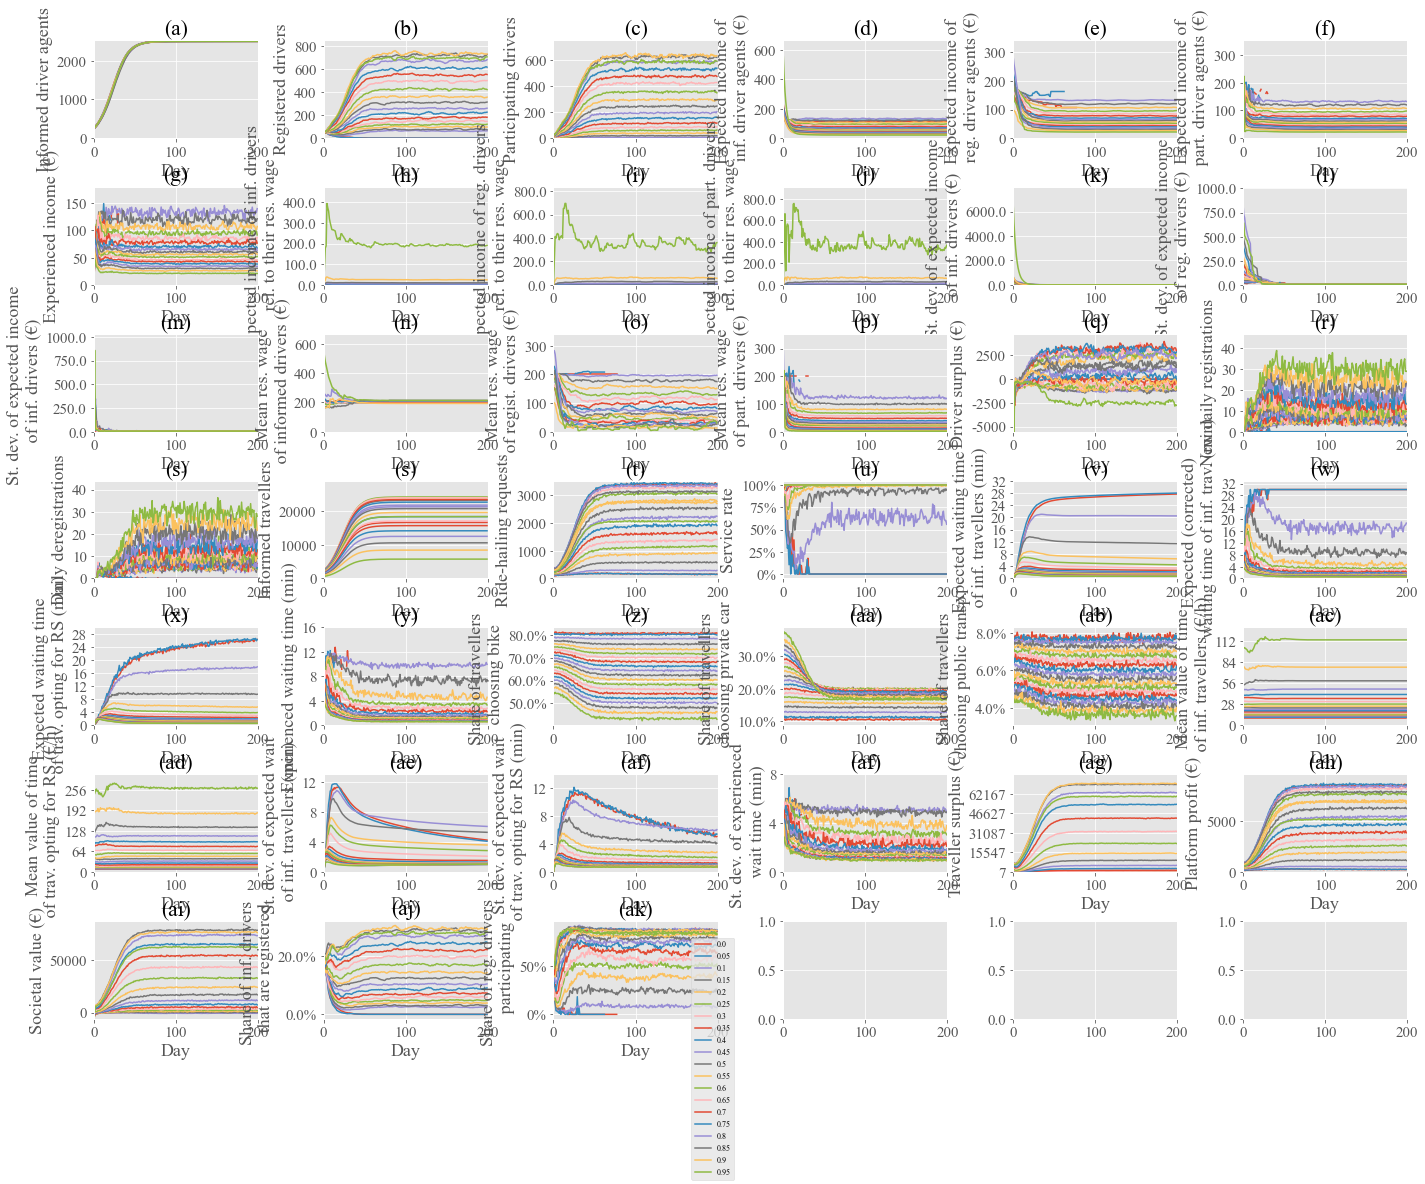

In [12]:
# Plot evolution of all indicators in one graph
fig = plot_multi_graph(res_scn, vals)
fig.savefig(os.path.join(os.getcwd(),"plots",variables["variable_1"]["name"], variables["variable_1"]["name"] + '_multi_fig.jpg'),dpi=300,bbox_inches='tight')

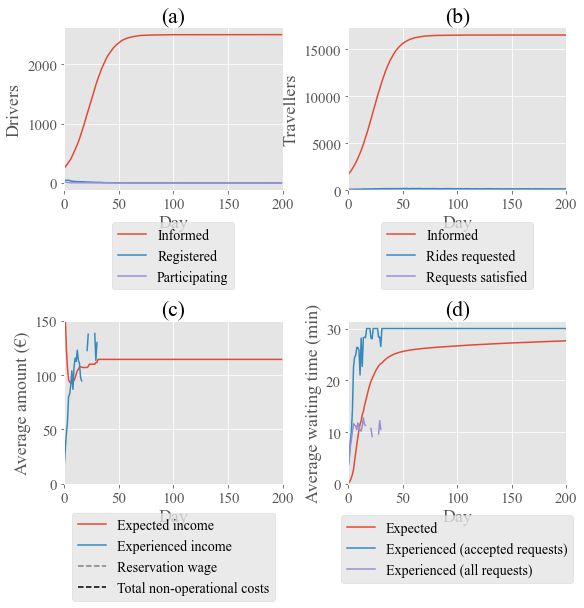

In [13]:
# Plot indicators for single scenario (e.g. base scenario)
value = var_val[0] # specific scenario
fig = plot_single_scenario(res_scn, value)
fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

In [14]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']
kpis_soc = ['soc_value']

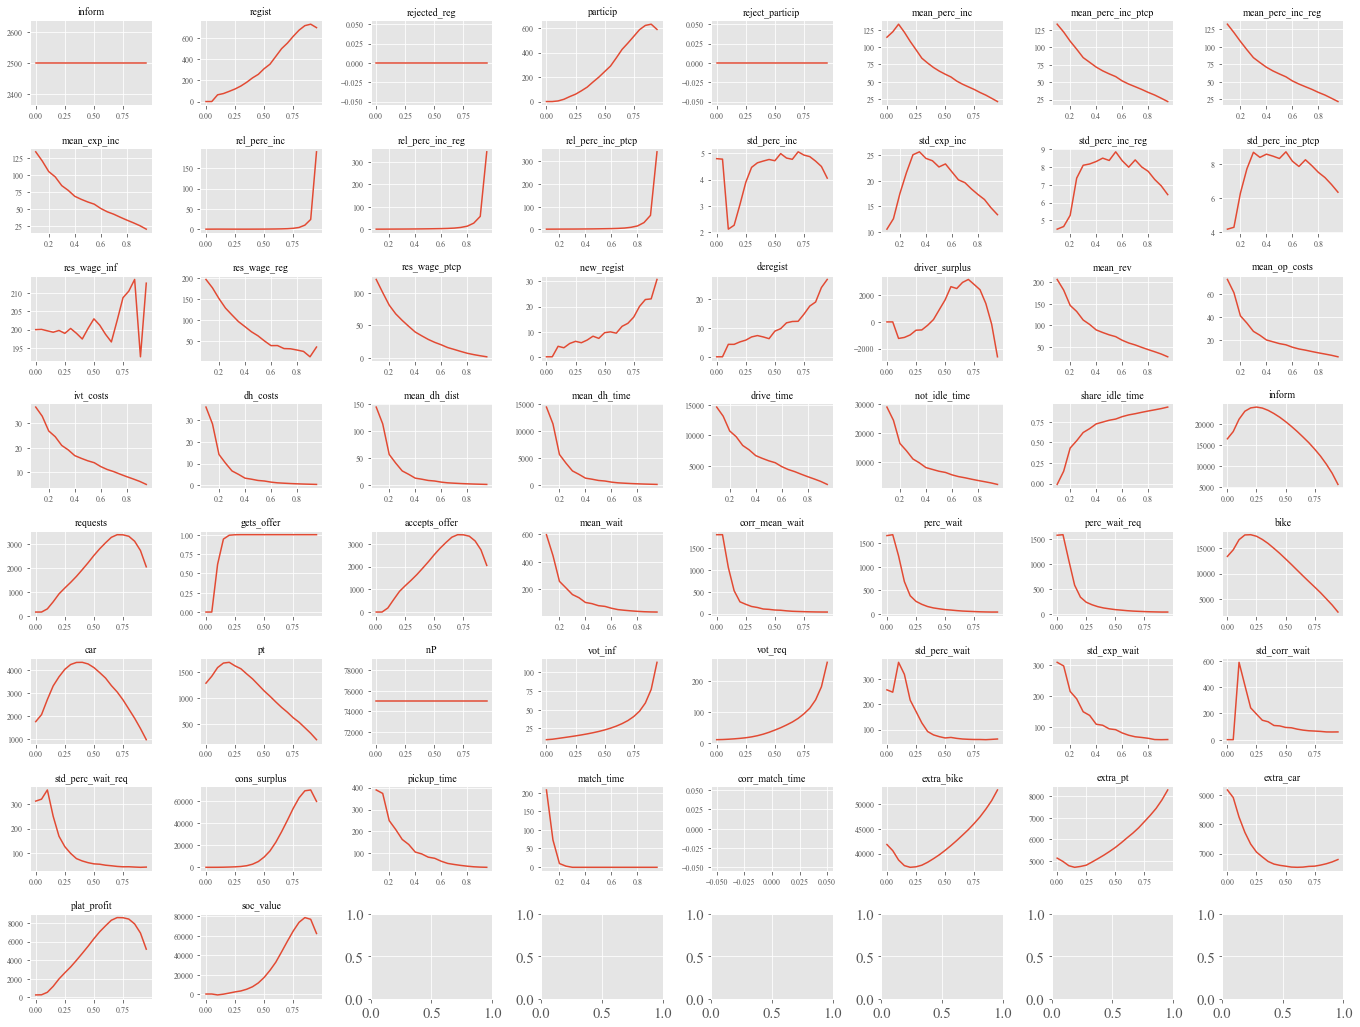

In [17]:
fig, axes = plt.subplots(8, 8, figsize = [24,18])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)
i = 0
j = 0

for kpi in kpis_sup:
    axes[j, i] = eql_scn.sup[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi,fontsize=10)
    axes[j, i].set(xlabel=None)
    axes[j, i].tick_params(axis='both', which='major', labelsize=8)
    i += 1
    if i > 7:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = eql_scn.dem[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi,fontsize=10)
    axes[j, i].set(xlabel=None)
    axes[j, i].tick_params(axis='both', which='major', labelsize=8)
    i += 1
    if i > 7:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = eql_scn.plf[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi,fontsize=10)
    axes[j, i].set(xlabel=None)
    axes[j, i].tick_params(axis='both', which='major', labelsize=8)
    i += 1
    if i > 7:
        i = 0
        j += 1
        
for kpi in kpis_soc:
    axes[j, i] = eql_scn.soc[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi,fontsize=10)
    axes[j, i].set(xlabel=None)
    axes[j, i].tick_params(axis='both', which='major', labelsize=8)
    i += 1
    if i > 7:
        i = 0
        j += 1

fig.savefig(os.path.join(os.getcwd(),"plots",variables["variable_1"]["name"], 'effect.jpg'),dpi=300,bbox_inches='tight')

In [18]:
# Compute additional indicators
res_proc = add_eql_supply_indicators(eql_scn, params)
res_proc.head(5)

,exp_inc,wait_time,driv_per_req,mode_share,earn_req_sat,serv_req_part,regist,ptcp_prob,match_rate,match_time,pickup_time,dh_time,idle_time
scenario,,,,,,,,,,,,,
0.00,NaN,NaN,0.000000,0.002014,NaN,NaN,0.00000,NaN,0.000000,NaN,NaN,NaN,NaN
0.05,NaN,NaN,0.000000,0.002020,NaN,NaN,0.00000,NaN,0.000000,NaN,NaN,NaN,NaN
0.10,133.947121,9.944255,0.017311,0.003793,3.754989,35.671779,0.02541,0.077529,0.617517,3.455754,6.488501,0.501795,-0.009826
0.15,120.630173,7.428749,0.031556,0.007753,4.035416,29.892871,0.03022,0.242886,0.943309,1.204723,6.224026,0.393801,0.149983
0.20,105.139620,4.301039,0.044042,0.012185,4.662550,22.549813,0.03856,0.417531,0.993139,0.143024,4.158015,0.197091,0.430403


In [19]:
# Compute market share of specific sub groups (based on VoT and res wage)
complete_df = pd.DataFrame(columns=all_pax[0].columns)
complete_df_sup = pd.DataFrame(columns=drivers[0].columns)
for i in vals:
    run_ids = scn[scn['val'] == i].index
    temp = all_pax[run_ids[0]]
    for j in run_ids[:3]:
        temp.append(all_pax[j])
        temp['scn'] = i
        temp['filter_pax_id'] = (temp['mode_choice'] == 'day-to-day').cumsum()
        temp['filter_pax_id'] = temp['filter_pax_id'] * (temp['mode_choice'] == 'day-to-day')
        temp['filter_pax_id'] = temp['filter_pax_id'].replace(0, np.nan)
        sel_req = micro.dem.requests[j][micro.dem.requests[j]['199']]
        temp['req'] = temp['filter_pax_id'].apply(lambda x: x in sel_req.index.values)
        temp_sup = pd.DataFrame(drivers[j])
        temp_sup['scn'] = i
        temp_sup['ptcp'] = micro.sup.ptcp[j]['199']
        temp_sup['exp_inc'] = micro.sup.exp_inc[j]['199'] / 8
        complete_df = complete_df.append(temp)
        complete_df_sup = complete_df_sup.append(temp_sup)
complete_df['pax_id'] = complete_df.index
complete_df = complete_df.reset_index(drop=True)
complete_df_sup['res_wage_hour'] = complete_df_sup['res_wage'] / 8
complete_df

abc = complete_df_sup.copy()
abc['wage_true'] = True
abc['value'] = abc['res_wage_hour'] * abc['ptcp'].apply(lambda x: 1 if x else np.nan)
defg = complete_df_sup.copy()
defg['wage_true'] = False
defg['value'] = defg['exp_inc']
abc = abc.append(defg)
abc[abc['scn']==0.9]['value'].sum()
defg[defg['scn']==0.9]['value'].sum()
abc[abc['scn']==0.9]['exp_inc'].count()
abc[abc['scn']==0.9]['res_wage_hour'].apply(lambda x: 1 if x else np.nan)

ms_scn = list()
for i in vals:
    temp_df = complete_df[complete_df['scn'] == i]
    temp_df = temp_df.sort_values(by=['VoT'],ascending=False).head(int(len(temp_df)*0.05))
    ms = temp_df.req.sum() / len(temp_df)
    ms_scn.append(ms)
ms_scn

res_proc['ms_95'] = ms_scn

ms_scn = list()
for i in vals:
    temp_df = complete_df[complete_df['scn'] == i]
    temp_df = temp_df.sort_values(by=['VoT'],ascending=False).head(int(len(temp_df)*0.25))
    ms = temp_df.req.sum() / len(temp_df)
    ms_scn.append(ms)
ms_scn
res_proc['ms_75'] = ms_scn

ms_scn = list()
for i in vals:
    temp_df = complete_df[complete_df['scn'] == i]
    temp_df = temp_df.sort_values(by=['VoT'],ascending=False).tail(int(len(temp_df)*0.25))
    ms = temp_df.req.sum() / len(temp_df)
    ms_scn.append(ms)
ms_scn
res_proc['ms_25'] = ms_scn

ms_scn = list()
for i in vals:
    temp_df = abc[abc['scn'] == i]
    temp_df = temp_df.sort_values(by=['res_wage'],ascending=True).head(int(len(temp_df)*0.05))
    ms = temp_df.ptcp.sum() / len(temp_df)
    ms_scn.append(ms)
ms_scn
res_proc['ls_5'] = ms_scn

ms_scn = list()
for i in vals:
    temp_df = abc[abc['scn'] == i]
    temp_df = temp_df.sort_values(by=['res_wage'],ascending=True).head(int(len(temp_df)*0.25))
    ms = temp_df.ptcp.sum() / len(temp_df)
    ms_scn.append(ms)
ms_scn
res_proc['ls_25'] = ms_scn

res_proc.head(5)

,exp_inc,wait_time,driv_per_req,mode_share,earn_req_sat,serv_req_part,regist,ptcp_prob,match_rate,match_time,pickup_time,dh_time,idle_time,ms_95,ms_75,ms_25,ls_5,ls_25
scenario,,,,,,,,,,,,,,,,,,
0.00,NaN,NaN,0.000000,0.002014,NaN,NaN,0.00000,NaN,0.000000,NaN,NaN,NaN,NaN,0.002133,0.002151,0.001671,0.000000,0.000000
0.05,NaN,NaN,0.000000,0.002020,NaN,NaN,0.00000,NaN,0.000000,NaN,NaN,NaN,NaN,0.004533,0.003164,0.000604,0.000000,0.000000
0.10,133.947121,9.944255,0.017311,0.003793,3.754989,35.671779,0.02541,0.077529,0.617517,3.455754,6.488501,0.501795,-0.009826,0.012178,0.008996,0.000213,0.032000,0.006400
0.15,120.630173,7.428749,0.031556,0.007753,4.035416,29.892871,0.03022,0.242886,0.943309,1.204723,6.224026,0.393801,0.149983,0.023644,0.020729,0.000089,0.133333,0.029867
0.20,105.139620,4.301039,0.044042,0.012185,4.662550,22.549813,0.03856,0.417531,0.993139,0.143024,4.158015,0.197091,0.430403,0.035733,0.033867,0.000036,0.309333,0.062933


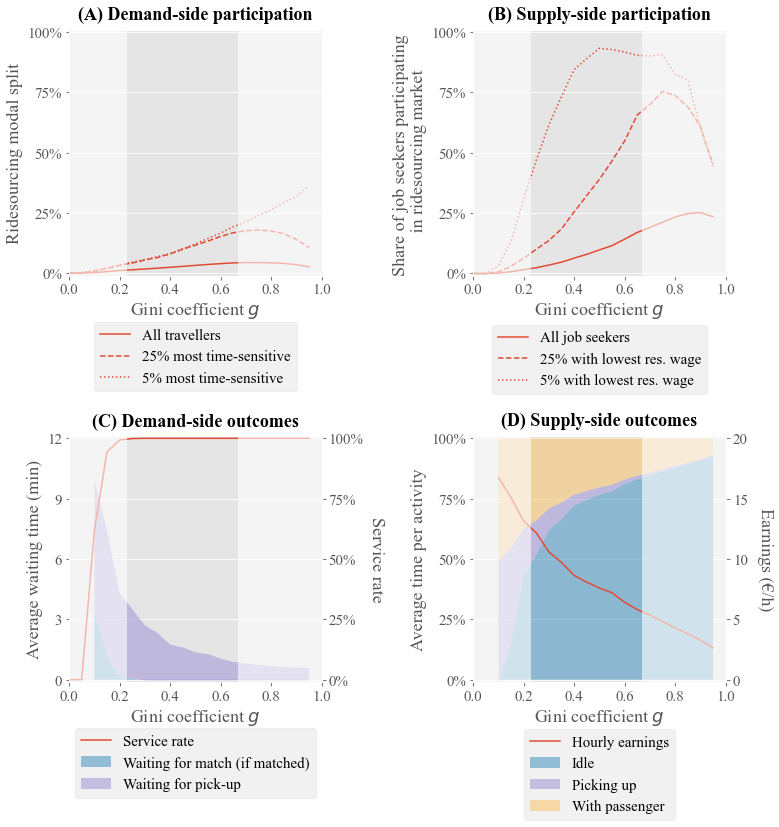

In [20]:
# Plot indicators

fig, axes = plt.subplots(2, 2, figsize = [12,12],sharex=False)
fig.subplots_adjust(hspace=.65, wspace=0.6, left=.12, right=.88)
plt.setp(axes, xlim=[0,1],xticks=np.arange(0, 1.2, step=0.2))
gini_min = 0.23
gini_max = 0.67

res_proc['tot_ptcp'] = (res_proc.regist * res_proc.ptcp_prob)
res_proc['tot_ptcp'].fillna(0, inplace=True)

res_proc.tot_ptcp.plot(ax=axes[0,1],legend=None,color='#E24A33')
res_proc.ls_25.plot(ax=axes[0,1],legend=None, marker='',color='#E24A33',linestyle='dashed')
res_proc.ls_5.plot(ax=axes[0,1],legend=None, marker='',color='#E24A33',linestyle='dotted')
axes[0, 1].set_ylabel('Share of job seekers participating \n in ridesourcing market')
axes[0, 1].set_xlabel('Gini coefficient $g$')
axes[0, 1].set_title('(B) Supply-side participation',fontweight="bold",pad=10,fontsize=18)
axes[0, 1].set_ylim(-0.01, top = 1.01)
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1,decimals=0)) 
axes[0, 1].yaxis.set_ticks([0,0.25,0.5,0.75,1])    
axes[0, 1].locator_params(axis='y', nbins=5)
axes[0, 1].axvspan(0, gini_min, facecolor='1.0', alpha=0.6,zorder=10)
axes[0, 1].axvspan(gini_max, 1, facecolor='1.0', alpha=0.6,zorder=10)
axes[0, 1].legend(['All job seekers','25% with lowest res. wage','5% with lowest res. wage'],fontsize=15, loc='lower center',framealpha=0.5,bbox_to_anchor=(0.5, -0.51))
axes[0, 1].grid(axis='x')

res_proc.mode_share.plot(ax=axes[0,0],legend=None, marker='',color='#E24A33')
res_proc.ms_75.plot(ax=axes[0,0],legend=None, marker='', linestyle='dashed', color='#E24A33')
res_proc.ms_95.plot(ax=axes[0,0],legend=None, marker='', linestyle='dotted', color='#E24A33')
axes[0, 0].set_ylabel('Ridesourcing modal split')
axes[0, 0].set_xlabel('Gini coefficient $g$')
axes[0, 0].set_title('(A) Demand-side participation', fontweight="bold",pad=10,fontsize=18)
axes[0, 0].set_ylim(bottom = -0.01, top = 1.01)
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1,decimals=0)) 
axes[0, 0].locator_params(axis='y', nbins=5)
axes[0, 0].axvspan(0, gini_min, facecolor='1.0', alpha=0.6,zorder=10)
axes[0, 0].axvspan(gini_max, 1, facecolor='1.0', alpha=0.6,zorder=10)
axes[0, 0].grid(axis='x')
axes[0, 0].legend(['All travellers','25% most time-sensitive','5% most time-sensitive'],fontsize=15, loc='lower center',framealpha=0.5,bbox_to_anchor=(0.5, -0.5))

(res_proc.match_rate *12).plot(ax=axes[1,0],legend=None, marker='',color='#E24A33')
axes[1, 0].set_xlabel('Gini coefficient $g$')
axes[1, 0].set_ylabel('Average waiting time (min)')
axes[1, 0].set_title('(C) Demand-side outcomes', fontweight="bold",pad=10,fontsize=18) 
axes[1, 0].locator_params(axis='y', nbins=5)

ax0 = axes[1,0].twinx()
axes[1,0].set_zorder(1)  # default zorder is 0 for ax1 and ax2
axes[1,0].set_frame_on(True)

res_proc.match_rate.plot(ax=ax0,legend=None, marker='',color='#E24A33',zorder=1)
ax0.set_ylim(bottom = -0.01, top = 1.01)
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
ax0.yaxis.set_ticks([0,0.25,0.5,0.75,1])
ax0.locator_params(axis='y', nbins=5)
ax0.set_ylabel('Service rate',rotation=270,labelpad=20)

x = res_proc.index.values
y1 = res_proc.match_time
y2 = res_proc.pickup_time
axes[1, 0].stackplot(x,y1,y2, alpha=0.5, colors=["#348ABD", "#988ED5", "#777777", "#FBC15E", "#8EBA42", "#FFB5B8"])
axes[1, 0].set_ylim(bottom = -0.12, top = 12.12)
axes[1, 0].yaxis.set_ticks([0,3,6,9,12])    
axes[1, 0].locator_params(axis='y', nbins=7)
axes[1, 0].legend(['Service rate','Waiting for match (if matched)','Waiting for pick-up'],fontsize=15,framealpha=0.5,loc='lower center',bbox_to_anchor=(0.5, -0.5))
axes[1, 0].axvspan(0, gini_min, facecolor='1.0', alpha=0.6,zorder=10)
axes[1, 0].axvspan(gini_max, 1, facecolor='1.0', alpha=0.6,zorder=10)
axes[1, 0].grid(axis='x')

res_proc['dh_time'] = eql_scn.sup.mean_dh_time / (params[0]['simTime'] * 3600)
x = res_proc.index.values
y1 = res_proc.idle_time
y2 = res_proc.dh_time
y3 = 1 - y1 - y2
axes[1, 1].stackplot(x,y1,y2,y3, alpha=0.5, colors=["#348ABD", "#988ED5", "#FBC15E", "#8EBA42", "#FFB5B8"])

ax1 = axes[1,1].twinx()
axes[1,1].set_zorder(1)  # default zorder is 0 for ax1 and ax2
axes[1,1].set_frame_on(True)
(res_proc.exp_inc/8/20).plot(ax=axes[1,1],legend=None, marker='',color='#E24A33')

(res_proc.exp_inc/8).plot(ax=ax1,legend=None, marker='',color='#E24A33')
ax1.set_ylim(bottom = -0.2, top = 20.2)
ax1.yaxis.set_ticks([0,5,10,15,20])
ax1.set_ylabel('Earnings (€/h)',rotation=270,labelpad=25)

axes[1, 1].set_ylabel('Average time per activity')
axes[1, 1].set_xlabel('Gini coefficient $g$')
axes[1, 1].set_title('(D) Supply-side outcomes', fontweight="bold",pad=10,fontsize=18)
axes[1, 1].set_ylim(bottom = -0.01, top = 1.01)
axes[1, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[1, 1].yaxis.set_ticks([0,0.25,0.5,0.75,1])    
axes[1, 1].locator_params(axis='y', nbins=5)
axes[1, 1].legend(['Hourly earnings','Idle','Picking up','With passenger'],loc='lower center',fontsize=15,framealpha=0.5,bbox_to_anchor=(0.5, -0.59))
axes[1, 1].axvspan(0, gini_min, facecolor='1.0', alpha=0.6,zorder=10)
axes[1, 1].axvspan(gini_max, 1, facecolor='1.0', alpha=0.6,zorder=10)
axes[1, 1].grid(axis='x')

axes[0, 1].tick_params(labelbottom=True)    
axes[0, 1].xaxis.get_label().set_visible(True)

fig.savefig(os.path.join(os.getcwd(),"plots",variables["variable_1"]["name"], 'indicators.jpg'),dpi=300,bbox_inches='tight')

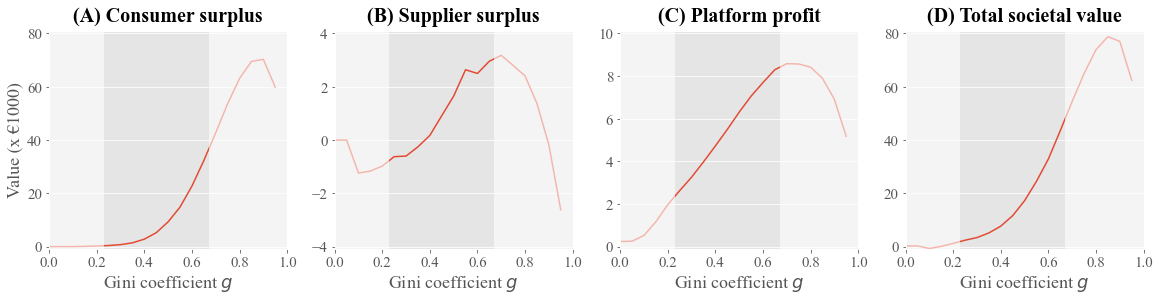

In [22]:
# Plot societal indicators
fig, axes = plt.subplots(1, 4, figsize = [20,4])
fig.subplots_adjust(hspace=.5, wspace=0.2, left=.12, right=.88)

axes[1] = (eql_scn.sup.driver_surplus/1000).plot(ax=axes[1])
axes[1].set_title('(B) Supplier surplus',fontweight="bold",pad=10, fontsize=20)
axes[1].set_xlabel('Gini coefficient $g$')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([-4.08,4.08])
axes[0].set_ylabel('Value (x \u20ac1000)')
axes[1].axvspan(0, gini_min, facecolor='1.0', alpha=0.6,zorder=10)
axes[1].axvspan(gini_max, 1, facecolor='1.0', alpha=0.6,zorder=10)
axes[1].grid(axis='x')

axes[0] = (eql_scn.dem.cons_surplus/1000).plot(ax=axes[0])
axes[0].set_title('(A) Consumer surplus',fontweight="bold",pad=10,fontsize=20)
axes[0].set_xlabel('Gini coefficient $g$')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([-0.8,80.8])
axes[0].grid(axis='x')
axes[0].axvspan(0, gini_min, facecolor='1.0', alpha=0.6,zorder=10)
axes[0].axvspan(gini_max, 1, facecolor='1.0', alpha=0.6,zorder=10)

axes[2] = (eql_scn.plf.plat_profit/1000).plot(ax=axes[2])
axes[2].set_title('(C) Platform profit',fontweight="bold",pad=10,fontsize=20)
axes[2].set_xlabel('Gini coefficient $g$')
axes[2].set_xlim([0, 1])
axes[2].set_ylim([-0.1,10.1])
axes[2].axvspan(0, gini_min, facecolor='1.0', alpha=0.6,zorder=10)
axes[2].axvspan(gini_max, 1, facecolor='1.0', alpha=0.6,zorder=10)
axes[2].grid(axis='x')

axes[3] = (eql_scn.soc.soc_value/1000).plot(ax=axes[3])
axes[3].set_title('(D) Total societal value',fontweight="bold",pad=10,fontsize=20)
axes[3].set_xlabel('Gini coefficient $g$')
axes[3].set_xlim([0, 1])
axes[3].set_ylim([-0.8,80.8])
axes[3].axvspan(0, gini_min, facecolor='1.0', alpha=0.6,zorder=10)
axes[3].axvspan(gini_max, 1, facecolor='1.0', alpha=0.6,zorder=10)
axes[3].grid(axis='x')

fig.savefig(os.path.join(os.getcwd(),"plots",variables["variable_1"]["name"], 'societal_value.jpg'),dpi=300,bbox_inches='tight')

[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
['ref-line']


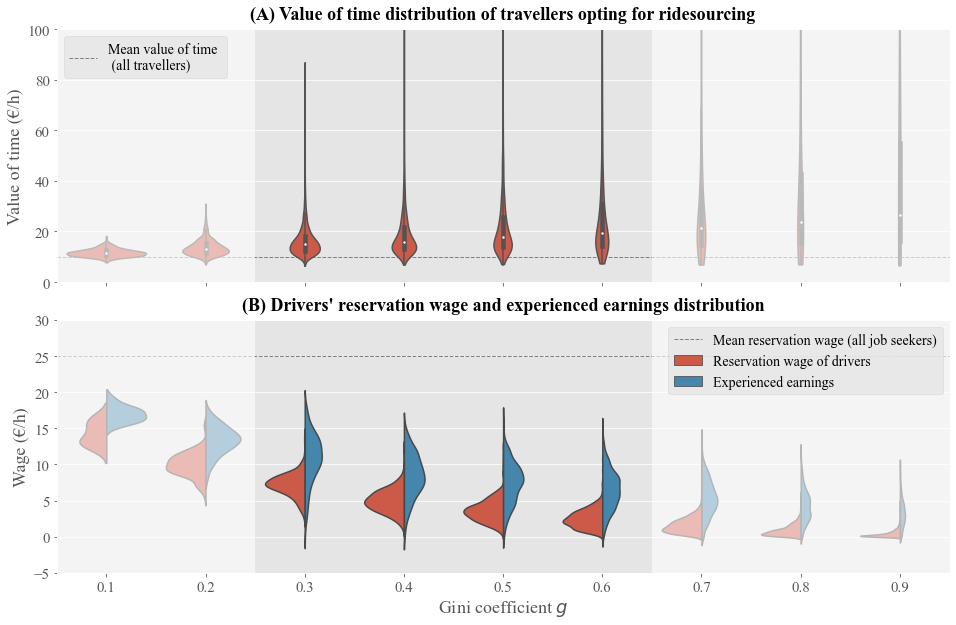

In [24]:
# sel_vals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
sel_vals = list(np.arange(10,100,10)/100)
print(sel_vals)

fig, axes = plt.subplots(2, 1, figsize = [16,10],sharex=True)
fig.subplots_adjust(hspace=.15)

axes[1] = sns.violinplot(data=abc[abc['scn'].isin(sel_vals)],y="value",x="scn",hue="wage_true",orient='v',split=True,inner=None,scale="area",scale_hue=True, hue_order= [True, False], ax=axes[1], palette=["#E24A33","#348ABD"],bw='scott')
axes[1].axhline(y=25,linewidth=1, color='grey',linestyle='--')
axes[1].set(ylim=(-5, 30))
axes[1].set(xlim=(-0.5,1))
axes[1].set_xlabel('Gini coefficient $g$')
axes[1].set_ylabel('Wage (€/h)')
axes[1].set_title('(B) Drivers\' reservation wage and experienced earnings distribution',fontweight="bold",pad=10,fontsize=18)
axes[0].xaxis.label.set_visible(False)
axes[1].axvspan(-0.5, 1.5, facecolor='1.0', alpha=0.6,zorder=10)
axes[1].axvspan(5.5, 10, facecolor='1.0', alpha=0.6,zorder=10)
axes[1].legend(['Mean reservation wage (all job seekers)','Reservation wage of drivers','Experienced earnings'],fontsize=14,loc='upper right').set_zorder(100)
fig.savefig(os.path.join(os.getcwd(),"plots",variables["variable_1"]["name"], 'wage-earnings.jpg'),dpi=300,bbox_inches='tight')

select_df = complete_df.loc[complete_df['req']]

axes[0] = sns.violinplot(data=select_df[select_df['scn'].isin(sel_vals)],x="scn",y="VoT",split=False,inner='box',cut=0,palette=['#E24A33','#E24A33','#E24A33','#E24A33','#E24A33','#E24A33','#E24A33','#E24A33','#E24A33',"#E24A33", "#988ED5", "#FBC15E", "#8EBA42", "#FFB5B8"],bw='scott', scale="area", scale_hue=False, ax=axes[0],gridsize=1000,label='vot')
axes[0].set(ylim=(0, 100))
axes[0].axhline(y=10,linewidth=1, color='grey',linestyle='--',zorder=-1,label='ref-line')
axes[0].set_ylabel('Value of time (€/h)')
axes[0].set_xlabel('Gini coefficient')
axes[0].set_title('(A) Value of time distribution of travellers opting for ridesourcing',fontweight="bold",pad=10,fontsize=18)
axes[0].axvspan(-0.5, 1.5, facecolor='1.0', alpha=0.6,zorder=10)
axes[0].axvspan(5.5, 10, facecolor='1.0', alpha=0.6,zorder=10)

handles,labels = axes[0].get_legend_handles_labels()
print(handles)
print(labels)

handles = [handles[0]]
labels = [labels[0]]

axes[0].legend(handles,['Mean value of time \n (all travellers)'],fontsize=14, loc='upper left').set_zorder(100)

fig.savefig(os.path.join(os.getcwd(),"plots",variables["variable_1"]["name"], 'heterog.jpg'),dpi=300,bbox_inches='tight')

In [25]:
sel_vals = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
abc_sel = abc[abc['scn'].isin(sel_vals)]
abc_sel

,pos,res_wage,veh,scn,ptcp,exp_inc,res_wage_hour,wage_true,value
1,46482076,246.266211,1,0.2,False,NaN,30.783276,True,NaN
2,46517247,178.593837,2,0.2,False,NaN,22.324230,True,NaN
3,46253226,248.993429,3,0.2,False,NaN,31.124179,True,NaN
4,46392805,287.871493,4,0.2,False,NaN,35.983937,True,NaN
5,722976575,201.380564,5,0.2,False,NaN,25.172570,True,NaN
...,...,...,...,...,...,...,...,...,...
2496,46431377,14.112702,2496,0.7,False,NaN,1.764088,False,NaN
2497,46477622,108.555750,2497,0.7,False,NaN,13.569469,False,NaN
2498,46304126,348.276614,2498,0.7,False,NaN,43.534577,False,NaN
2499,46175654,49.291910,2499,0.7,False,NaN,6.161489,False,NaN


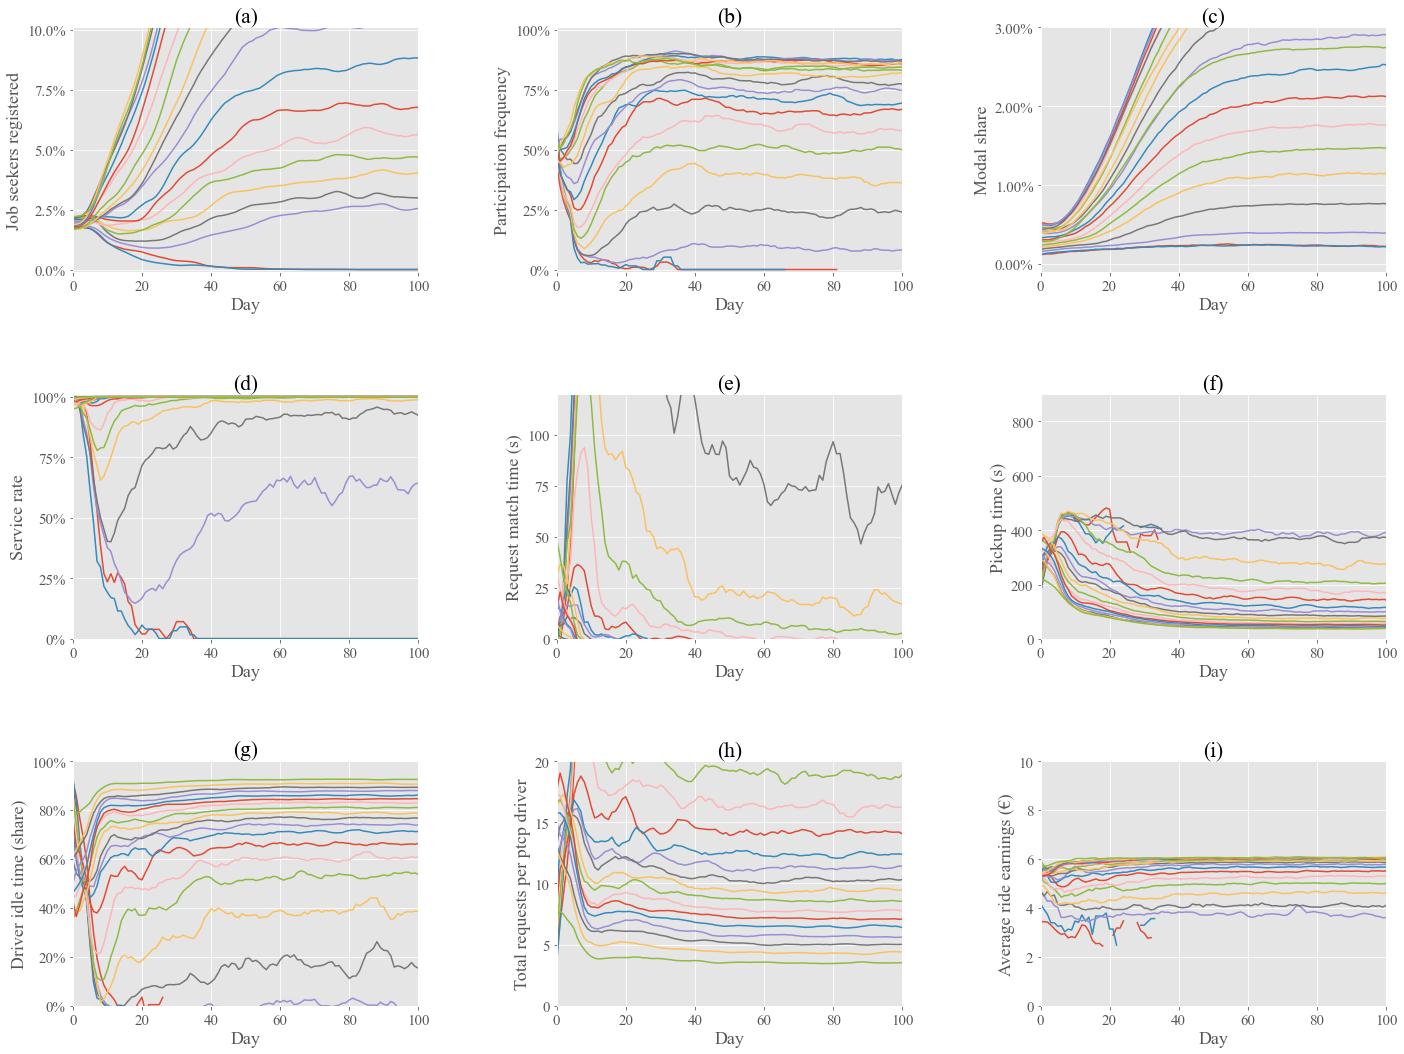

In [34]:
# Evolution of selected indicators
fig, axes = plt.subplots(3, 3, figsize = [24,18])
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)
plt.setp(axes, xlim=[0,100])

axes[0, 0].plot(res_scn.sup.regist.rolling(5, min_periods=1).mean() / 2500)
axes[0, 0].set_ylabel('Job seekers registered')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_title('(a)')
axes[0, 0].set_ylim(bottom = -0.001, top = 0.101)
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1)) 
axes[0, 0].locator_params(axis='y', nbins=5)

axes[0, 1].plot((res_scn.sup.particip / res_scn.sup.regist).rolling(5, min_periods=1).mean())
axes[0, 1].set_ylabel('Participation frequency')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_title('(b)')
axes[0, 1].set_ylim(bottom = -0.01, top = 1.01)
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 1].locator_params(axis='y', nbins=5)

axes[0, 2].plot(res_scn.dem.requests.rolling(5, min_periods=1).mean() / 75000)
axes[0, 2].set_ylabel('Modal share')
axes[0, 2].set_xlabel('Day')
axes[0, 2].set_title('(c)')
axes[0, 2].set_ylim(bottom = -0.001, top = 0.03)
axes[0, 2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0, 2].locator_params(axis='y', nbins=5)

axes[1, 0].plot(res_scn.dem.gets_offer.rolling(5, min_periods=1).mean())
axes[1, 0].set_ylabel('Service rate')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_title('(d)')
axes[1, 0].set_ylim(bottom = -0.001, top = 1.01)
axes[1, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1, 0].locator_params(axis='y', nbins=5)

axes[1, 1].plot(res_scn.dem.match_time.rolling(5, min_periods=1).mean())
axes[1, 1].set_ylabel('Request match time (s)')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_title('(e)')
axes[1, 1].set_ylim(bottom = 0, top = 120)
axes[1, 1].locator_params(axis='y', nbins=5)

axes[1, 2].plot(res_scn.dem.pickup_time.rolling(5, min_periods=1).mean())
axes[1, 2].set_ylabel('Pickup time (s)')
axes[1, 2].set_xlabel('Day')
axes[1, 2].set_title('(f)')
axes[1, 2].set_ylim(bottom = 0, top = 900)
axes[1, 2].locator_params(axis='y', nbins=5)

axes[2, 0].plot(res_scn.sup.share_idle_time.rolling(5, min_periods=1).mean())
axes[2, 0].set_ylabel('Driver idle time (share)')
axes[2, 0].set_xlabel('Day')
axes[2, 0].set_title('(g)')
axes[2, 0].set_ylim(bottom = 0, top = 1)
axes[2, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[2, 0].locator_params(axis='y', nbins=5)

axes[2, 1].plot((res_scn.dem.requests * res_scn.dem.gets_offer / res_scn.sup.particip).rolling(5, min_periods=1).mean())
axes[2, 1].set_ylabel('Total requests per ptcp driver')
axes[2, 1].set_xlabel('Day')
axes[2, 1].set_title('(h)')
axes[2, 1].set_ylim(bottom = 0, top = 20)
axes[2, 1].locator_params(axis='y', nbins=5)

axes[2, 2].plot((res_scn.sup.mean_exp_inc / (res_scn.dem.requests / res_scn.sup.particip * res_scn.dem.gets_offer)).rolling(3, min_periods=1).mean())
axes[2, 2].set_ylabel('Average ride earnings (€)')
axes[2, 2].set_xlabel('Day')
axes[2, 2].set_title('(i)')
axes[2, 2].set_ylim(bottom = 0, top = 10)
axes[2, 2].locator_params(axis='y', nbins=5)

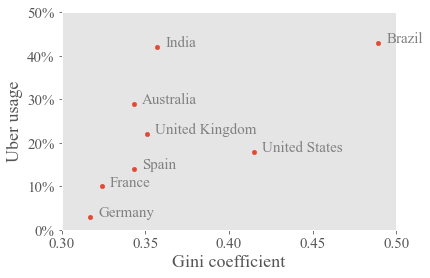

In [35]:
# Generate plot based on empirical data
emp_data = pd.read_csv('data/world_stats.csv',sep=';')
emp_data['Gini'] = emp_data['Gini'] / 100
emp_data.set_index('Country')

fig = plt.figure(figsize=[6,4])
ax = fig.add_subplot()

emp_data.plot.scatter(x='Gini',y='Statista Global Consumer Survey 2022 - share used last year',color='#E24A33',ax=ax)
ax.set_xlabel('Gini coefficient')
ax.set_ylabel('Uber usage')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1,decimals=0)) 
ax.set_xlim([0.3,0.5])
ax.set_ylim([0,0.5])
ax.grid(False)

# annotate points in axis
for idx, row in emp_data.iterrows():
    ax.annotate(row['Country'], (row['Gini']+0.005, row['Statista Global Consumer Survey 2022 - share used last year']+0.00007),color='grey')
    
fig.savefig(os.path.join(os.getcwd(),"plots",variables["variable_1"]["name"], 'emp_rel.jpg'),dpi=100,bbox_inches='tight')
plt.show()